# Assignment 2

## Problem 1

### Implement Gillespies algorithm

In [84]:
# Import libraries:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


In [85]:
# Define initial values, events and rates

# Initial population
N0 = 100000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Initial time
t = 0

# Step 1: Define events
events = [
    "birth",
    "transmission",
    "recovery",
    "death_X",
    "death_Y",
    "death_Z"
]

# Simulation time
t_max = 365  # 10 years

# Store the state after each event
times = [t]
X_values = [X]
Y_values = [Y]
Z_values = [Z]

In [86]:

while t < t_max:
    
    # Step 2: Calculate rates
    N = X + Y + Z

    rate_birth = mu * N
    rate_transmission = beta * X * Y / N
    rate_recovery = gamma * Y
    rate_death_X = mu * X
    rate_death_Y = mu * Y
    rate_death_Z = mu * Z

    # Step 3: Total rate
    R_total = (
        rate_birth
        + rate_transmission
        + rate_recovery
        + rate_death_X
        + rate_death_Y
        + rate_death_Z
    )

    # Step 4: Waiting time
    RAND_1 = np.random.rand()
    ## Determines when the next event happens

    delta_t = -np.log(RAND_1) / R_total

    # Step 5: Draw random number for event selection
    RAND_2 = np.random.rand()
    ## Determines which event happens next

    # Define P
    P = RAND_2 * R_total

    # Step 6: Select event
    cumulative_rates = np.cumsum([
        rate_birth,
        rate_transmission,
        rate_recovery,
        rate_death_X,
        rate_death_Y,
        rate_death_Z
    ])

    if P <= cumulative_rates[0]:
        event = 0

    elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
        event = 1

    elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
        event = 2

    elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
        event = 3

    elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
        event = 4

    else:
        event = 5

    # Step 7: Update time
    t += delta_t

    # Perform event
    if event == 0:
        X += 1

    elif event == 1:
        X -= 1
        Y += 1

    elif event == 2:
        Y -= 1
        Z += 1

    elif event == 3:
        X -= 1

    elif event == 4:
        Y -= 1

    elif event == 5:
        Z -= 1

    # Store the new state
    times.append(t)
    X_values.append(X)
    Y_values.append(Y)
    Z_values.append(Z)



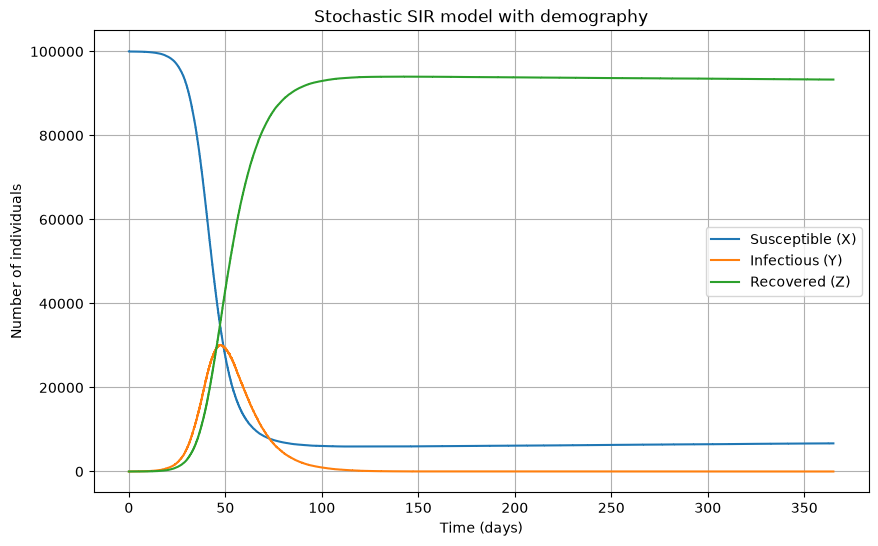

In [87]:
# Plot the Gillespie algorithm:

plt.figure(figsize=(10, 6))

plt.step(times, X_values, label="Susceptible (X)")
plt.step(times, Y_values, label="Infectious (Y)")
plt.step(times, Z_values, label="Recovered (Z)")

plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model with demography")
plt.legend()
plt.grid()

plt.show()

### Compare the GA Stochastic Simulation with an Equivalent Deterministic ODE Model

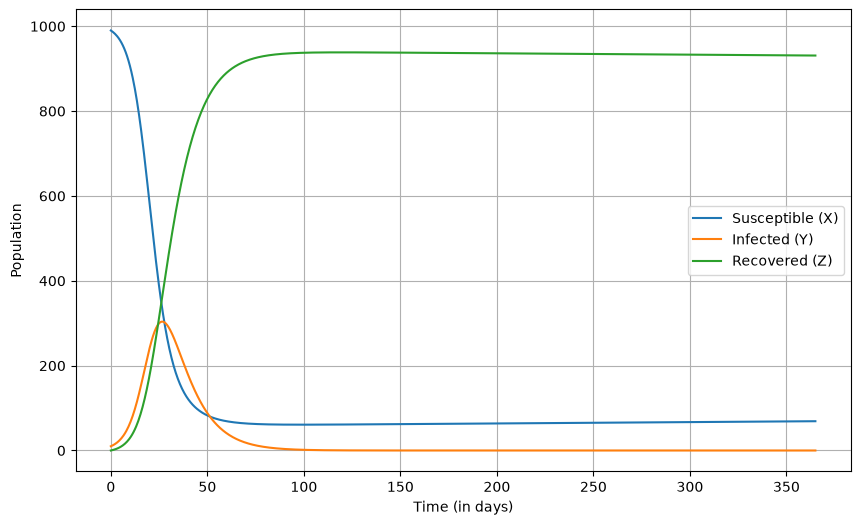

In [88]:
# Using the same initial values, events and rates

# Initial population
N0 = 1000

# Initial conditions
Y = 10
Z = 0
X = N0 - Y - Z
y0 = [X, Y, Z]

# Parameters measured in days
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Time - 1 year 
t = np.linspace(0,365,1000)


def model(y, t, beta, gamma, u):
    s, i, r = y
    N = s + i + r
    dsdt = u*N - beta*s*i/N - u*s
    didt = beta*s*i/N - gamma*i - u*i
    drdt = gamma*i - u*r
    return [dsdt, didt, drdt]

# Numerically integrate the ODE
solution = odeint(model, y0, t, args=(beta, gamma, mu))

s, i, r = solution.T

plt.figure(figsize=(10, 6))
plt.plot(t, s, label="Susceptible (X)")
plt.plot(t, i, label="Infected (Y)")
plt.plot(t, r, label="Recovered (Z)")
plt.xlabel("Time (in days)")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

Both graphs have the same overall shape, with small differences that come from chance from the stochastic model since it shows one possible version of the epidemic, while the ODE describes the average.

bonus:blablabla

### Investigate Simulation Variability 

In [89]:
# Define initial values, events and rates

# Initial population
N0_vary = [100, 500, 1000, 2000, 5000, 10000, 50000]
Y = []
X = []
Z = [0]*7

# Initial conditions
for i in N0_vary:
    y = 0.01*i
    Y.append(y)
    x = i-y
    X.append(x)
    
print(X, Y, Z)

# Parameters measured in days
beta_vary = [0.15, 0.2, 0.3, 0.5]
beta = 0.3
gamma = 0.1
mu = 1 / (80 * 365)

# Initial time
t = 0

# Step 1: Define events
events = [
    "birth",
    "transmission",
    "recovery",
    "death_X",
    "death_Y",
    "death_Z"
]

# Simulation time
t_max = 365  # 10 years

[99.0, 495.0, 990.0, 1980.0, 4950.0, 9900.0, 49500.0] [1.0, 5.0, 10.0, 20.0, 50.0, 100.0, 500.0] [0, 0, 0, 0, 0, 0, 0]


In [90]:
def simulation_variability(t, X, Y, Z, beta=beta):
    # Store the state after each event
    times = [t]
    X_values = [X]
    Y_values = [Y]
    Z_values = [Z]

    while t < t_max:
        
        # Step 2: Calculate rates
        N = X + Y + Z

        rate_birth = mu * N
        rate_transmission = beta * X * Y / N
        rate_recovery = gamma * Y
        rate_death_X = mu * X
        rate_death_Y = mu * Y
        rate_death_Z = mu * Z

        # Step 3: Total rate
        R_total = (
            rate_birth
            + rate_transmission
            + rate_recovery
            + rate_death_X
            + rate_death_Y
            + rate_death_Z
        )

        # Step 4: Waiting time
        RAND_1 = np.random.rand()
        ## Determines when the next event happens

        delta_t = -np.log(RAND_1) / R_total

        # Step 5: Draw random number for event selection
        RAND_2 = np.random.rand()
        ## Determines which event happens next

        # Define P
        P = RAND_2 * R_total

        # Step 6: Select event
        cumulative_rates = np.cumsum([
            rate_birth,
            rate_transmission,
            rate_recovery,
            rate_death_X,
            rate_death_Y,
            rate_death_Z
        ])

        if P <= cumulative_rates[0]:
            event = 0

        elif P > cumulative_rates[0] and P <= cumulative_rates[1]:
            event = 1

        elif P > cumulative_rates[1] and P <= cumulative_rates[2]:
            event = 2

        elif P > cumulative_rates[2] and P <= cumulative_rates[3]:
            event = 3

        elif P > cumulative_rates[3] and P <= cumulative_rates[4]:
            event = 4

        else:
            event = 5

        # Step 7: Update time
        t += delta_t

        # Perform event
        if event == 0:
            X += 1

        elif event == 1:
            X -= 1
            Y += 1

        elif event == 2:
            Y -= 1
            Z += 1

        elif event == 3:
            X -= 1

        elif event == 4:
            Y -= 1

        elif event == 5:
            Z -= 1

        # Store the new state
        times.append(t)
        X_values.append(X)
        Y_values.append(Y)
        Z_values.append(Z)
    return times, X_values, Y_values, Z_values


In [91]:

times_100, X_values_100, Y_values_100, Z_values_100 = simulation_variability(0, X[0], Y[0], Z[0])
times_500, X_values_500, Y_values_500, Z_values_500 = simulation_variability(0, X[1], Y[1], Z[1])
times_1000, X_values_1000, Y_values_1000, Z_values_1000 = simulation_variability(0, X[2], Y[2], Z[2])
times_2000, X_values_2000, Y_values_2000, Z_values_2000 = simulation_variability(0, X[3], Y[3], Z[3])
times_5000, X_values_5000, Y_values_5000, Z_values_5000 = simulation_variability(0, X[4], Y[4], Z[4])
times_10000, X_values_10000, Y_values_10000, Z_values_10000 = simulation_variability(0, X[5], Y[5], Z[5])
times_50000, X_values_50000, Y_values_50000, Z_values_50000 = simulation_variability(0, X[6], Y[6], Z[6])


In [92]:
times_015, X_values_015, Y_values_015, Z_values_015 = simulation_variability(0, X[2], Y[2], Z[2], beta_vary[0])
times_02, X_values_02, Y_values_02, Z_values_02 = simulation_variability(0, X[2], Y[2], Z[2], beta_vary[1])
times_03, X_values_03, Y_values_03, Z_values_03 = simulation_variability(0, X[2], Y[2], Z[2], beta_vary[2])
times_05, X_values_05, Y_values_05, Z_values_05 = simulation_variability(0, X[2], Y[2], Z[2], beta_vary[3])

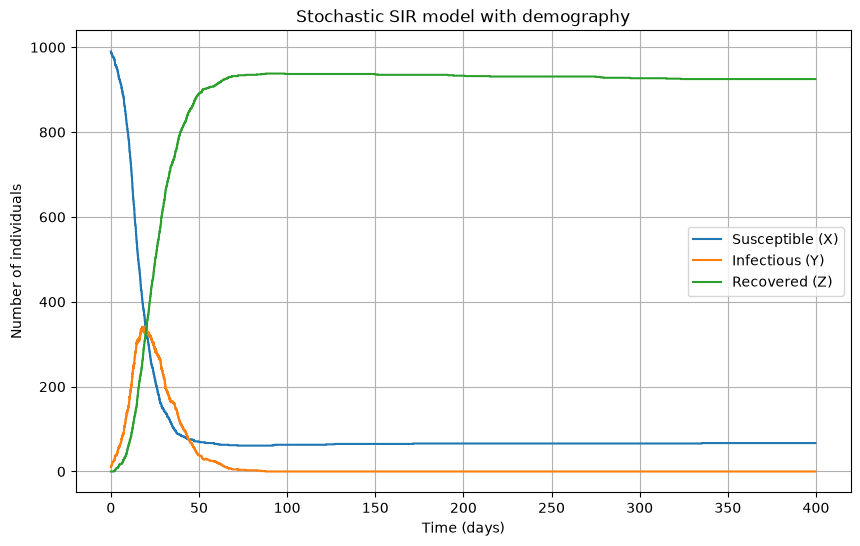

In [93]:
# Plot the Gillespie algorithm:

plt.figure(figsize=(10, 6))

plt.step(times_03, X_values_03, label="Susceptible (X)")
plt.step(times_03, Y_values_03, label="Infectious (Y)")
plt.step(times_03, Z_values_03, label="Recovered (Z)")

plt.xlabel("Time (days)")
plt.ylabel("Number of individuals")
plt.title("Stochastic SIR model with demography")
plt.legend()
plt.grid()

plt.show()

In [ ]:
def run_simulations(N0, beta, Y0=None, n_runs=200):

    if Y0 is None:
        Y0 = 0.01 * N0

    all_simulations = []

    for i in range(n_runs):

        times, X_values, Y_values, Z_values = simulation_variability(
            0, N0 - Y0, Y0, 0, beta=beta
        )

        all_simulations.append(
            (np.array(times), np.array(X_values), np.array(Y_values), np.array(Z_values))
        )

    return all_simulations



def calculate_statistics(all_simulations):

    # Common time points: every day from 0 to 365
    time_grid = np.arange(0, 366)

    X_runs = []
    Y_runs = []
    Z_runs = []

    # Put every simulation onto the same time grid
    for times, X_values, Y_values, Z_values in all_simulations:

        indices = np.searchsorted(times, time_grid, side="right") - 1

        X_runs.append(X_values[indices])
        Y_runs.append(Y_values[indices])
        Z_runs.append(Z_values[indices])

    # Convert to arrays
    X_runs = np.array(X_runs)
    Y_runs = np.array(Y_runs)
    Z_runs = np.array(Z_runs)

    # Mean at each time point
    X_mean = np.mean(X_runs, axis=0)
    Y_mean = np.mean(Y_runs, axis=0)
    Z_mean = np.mean(Z_runs, axis=0)

    # Variance at each time point
    X_var = np.var(X_runs, axis=0)
    Y_var = np.var(Y_runs, axis=0)
    Z_var = np.var(Z_runs, axis=0)

    # Covariance between X and Y at each time point
    XY_cov = np.mean(
        (X_runs - X_mean) * (Y_runs - Y_mean),
        axis=0
    )

    return (
        time_grid,
        X_mean, Y_mean, Z_mean,
        X_var, Y_var, Z_var,
        XY_cov
    )



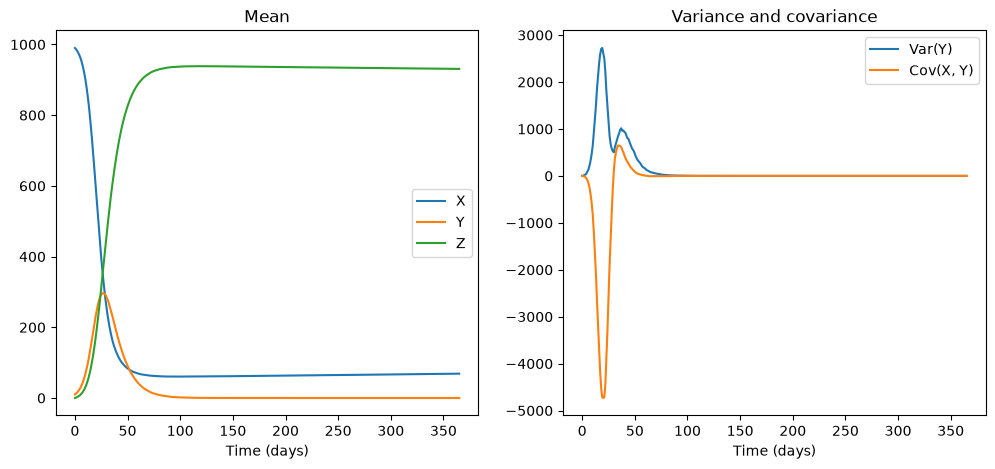

In [ ]:
# unused
scenario_100_simulations = run_simulations(100, 0.3)
time_grid, X_mean, Y_mean, Z_mean, X_var, Y_var, Z_var, XY_cov = calculate_statistics(all_simulations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Mean
ax1.plot(time_grid, X_mean, label="X")
ax1.plot(time_grid, Y_mean, label="Y")
ax1.plot(time_grid, Z_mean, label="Z")
ax1.set_title("Mean")
ax1.set_xlabel("Time (days)")
ax1.legend()

# Variance and covariance
ax2.plot(time_grid, Y_var, label="Var(Y)")
ax2.plot(time_grid, XY_cov, label="Cov(X, Y)")
ax2.set_title("Variance and covariance")
ax2.set_xlabel("Time (days)")
ax2.legend()

plt.show()


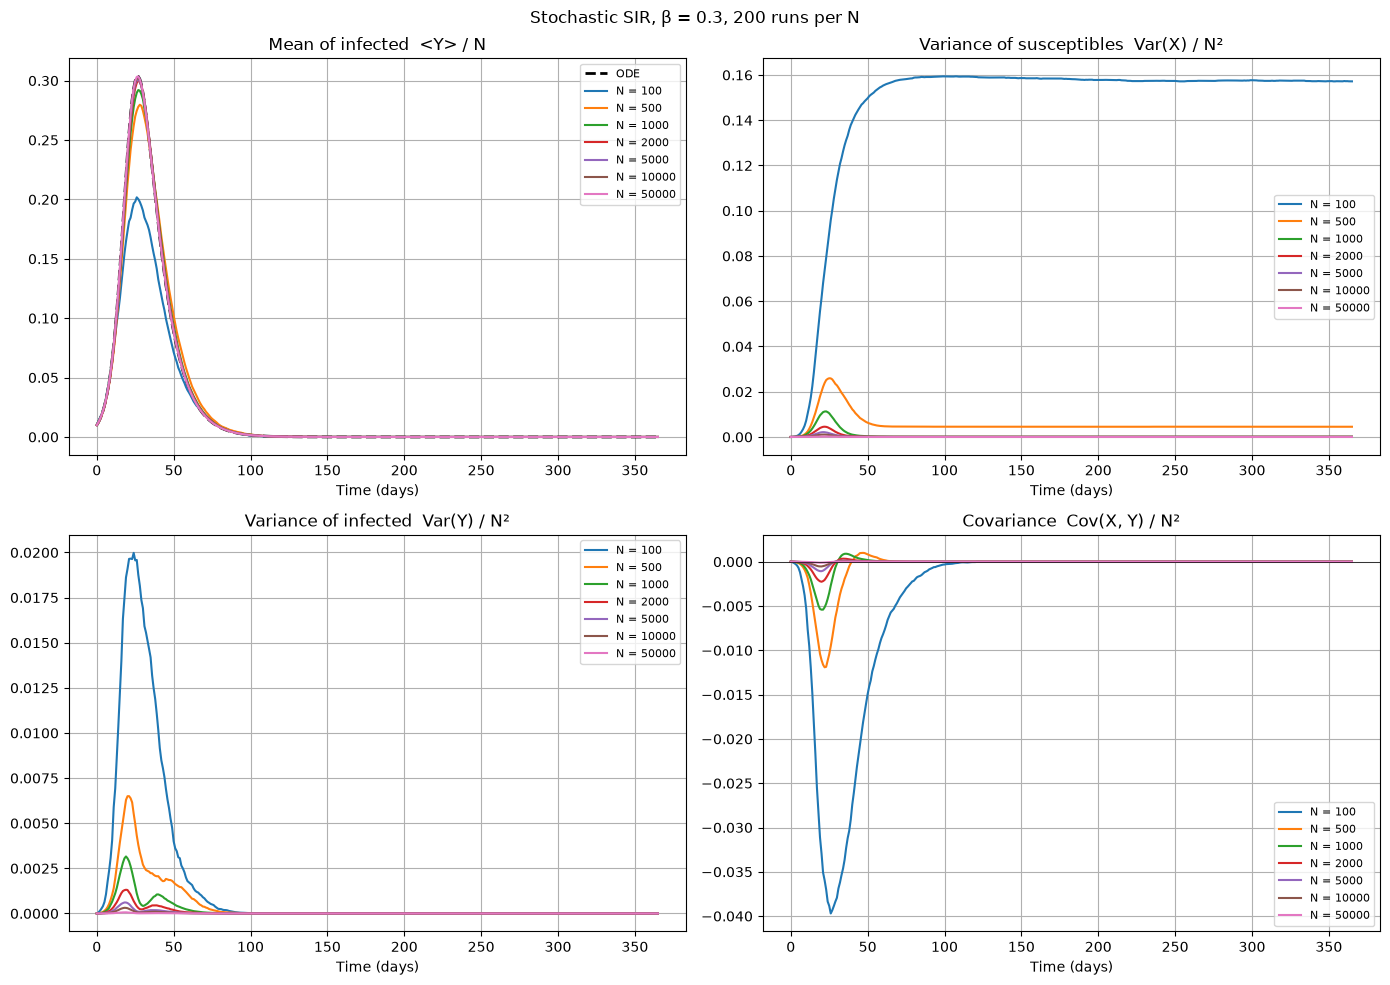

In [101]:
# Mean, variance and covariance for every population size N, with beta = 0.3
# Values are divided by N (mean) and N^2 (variance, covariance) so the scenarios can be compared on one plot

beta_fixed = 0.3

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_mean, ax_varX, ax_varY, ax_cov = axes.flatten()

# Deterministic ODE solution (as a fraction of N it is the same for every N, since Y0 = 1% of N)
ode_time = np.arange(0, 366)
ode_solution = odeint(model, [0.99, 0.01, 0], ode_time, args=(beta_fixed, gamma, mu))
ax_mean.plot(ode_time, ode_solution[:, 1], "k--", lw=2, label="ODE")

for N0 in N0_vary:
    simulations = run_simulations(N0, beta_fixed)
    time_grid, X_mean, Y_mean, Z_mean, X_var, Y_var, Z_var, XY_cov = calculate_statistics(simulations)

    ax_mean.plot(time_grid, Y_mean / N0, label=f"N = {N0}")
    ax_varX.plot(time_grid, X_var / N0**2, label=f"N = {N0}")
    ax_varY.plot(time_grid, Y_var / N0**2, label=f"N = {N0}")
    ax_cov.plot(time_grid, XY_cov / N0**2, label=f"N = {N0}")

ax_mean.set_title("Mean of infected  <Y> / N")
ax_varX.set_title("Variance of susceptibles  Var(X) / N²")
ax_varY.set_title("Variance of infected  Var(Y) / N²")
ax_cov.set_title("Covariance  Cov(X, Y) / N²")
ax_cov.axhline(0, color="k", lw=0.5)

for ax in axes.flatten():
    ax.set_xlabel("Time (days)")
    ax.grid()
    ax.legend(fontsize=8)

fig.suptitle(f"Stochastic SIR, β = {beta_fixed}, 200 runs per N")
plt.tight_layout()
plt.show()
